# Импорты и общие настройки

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from pathlib import Path
import json
from dataclasses import dataclass
import math
import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler


plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# Генерация синтетического датасета

In [2]:
def make_synthetic_series(n_days: int = 1100, start: str = "2021-01-01") -> pd.DataFrame:
    """Генерирует реалистичный синтетический временной ряд с несколькими компонентами."""
    dates = pd.date_range(start=start, periods=n_days, freq="D")
    t = np.arange(n_days)
    trend = 60 + 0.04 * t 
    weekly = 7 * np.sin(2 * np.pi * t / 7) + 2.5 * np.cos(2 * np.pi * t / 7) 
    long_wave = 9 * np.sin(2 * np.pi * t / 365.25) 
    noise = np.random.normal(0, 2.7, size=n_days)
    dow = pd.Series(dates).dt.dayofweek.to_numpy()
    weekend_bonus = np.where(dow >= 5, 4.5, 0.0)
    promo = np.zeros(n_days)
    promo_idx = np.random.choice(np.arange(20, n_days - 20), size=18, replace=False)
    promo[promo_idx] += np.random.uniform(8, 16, size=len(promo_idx))
    regime_shift = np.where(t > int(n_days * 0.78), 6.0, 0.0)
    y = trend + weekly + long_wave + weekend_bonus + promo + regime_shift + noise
    y = np.maximum(y, 0.1) 
    return pd.DataFrame({"date": dates, "value": y})

df = make_synthetic_series()
df_real = pd.read_csv("../data/energy_demand_hourly_brazil.csv")
target = "value"
target_col = df[target]

In [3]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70  
    val_frac: float = 0.15   

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    """
    Разбивает временной ряд на train/val/test по хронологии.
    ВАЖНО: не случайное разбиение, а последовательное по времени!ф
    Модель учится на прошлом и тестируется на будущем.
    """
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()       
    val_df = df.iloc[train_end:val_end].copy()   
    test_df = df.iloc[val_end:].copy()            
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (770, 2), 2021-01-01 -> 2023-02-09
val  : (165, 2), 2023-02-10 -> 2023-07-24
test : (165, 2), 2023-07-25 -> 2024-01-05


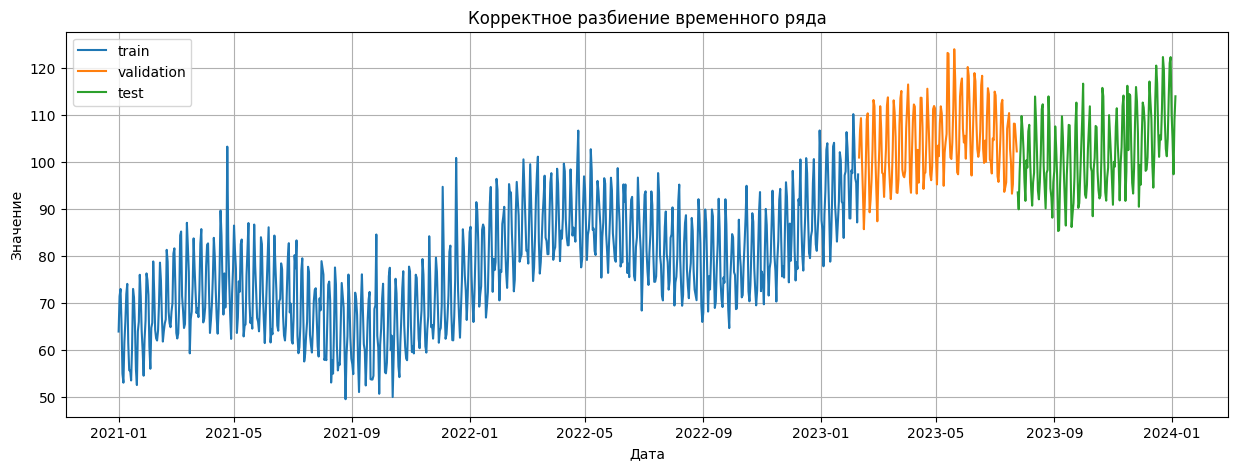

In [4]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["value"], label="train")
ax.plot(val_df["date"], val_df["value"], label="validation")
ax.plot(test_df["date"], test_df["value"], label="test")
ax.set_title("Корректное разбиение временного ряда")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

# Масштабирование и оконное представление

In [5]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["value"]]).astype(np.float32)  
val_scaled = scaler.transform(val_df[["value"]]).astype(np.float32)         
test_scaled = scaler.transform(test_df[["value"]]).astype(np.float32)

window_size = 28 

def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])      
        y.append(series_2d[i + window_size, 0])      
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (742, 28, 1) y_train: (742,)
X_val  : (137, 28, 1) y_val  : (137,)
X_test : (137, 28, 1) y_test : (137,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-1.1163124  -0.47837868 -0.3464519  -0.9770324  -1.8792725 ]
Цель: -0.91874194


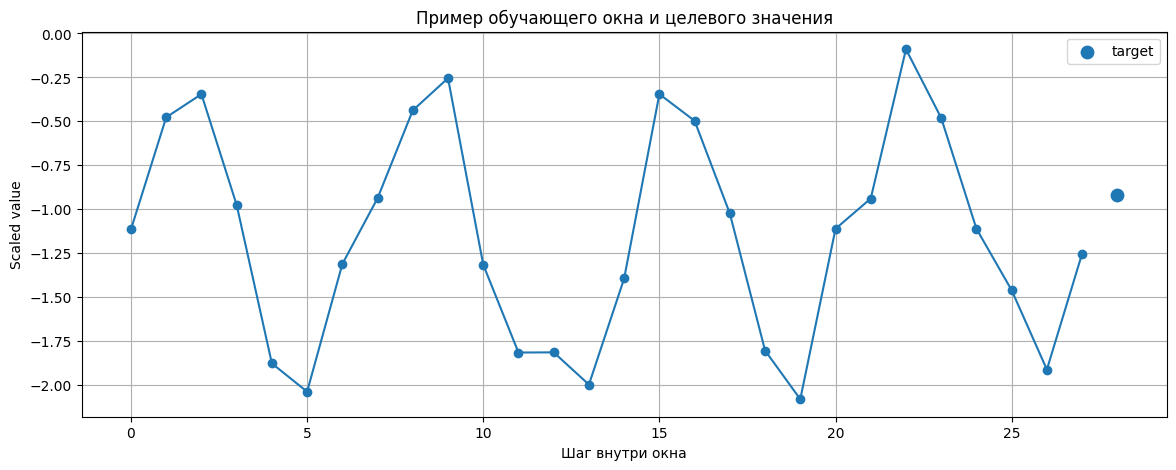

In [6]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [7]:
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)  

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64 

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True) 
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False) 
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  
print("Batch y:", yb.shape)  

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


# Признаки для бейзлайн моделей

In [8]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df, target)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,value,dayofweek,month,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2021-01-15,60.549335,4,1,53.435997,65.933209,63.841128,62.546560,8.257157
1,2021-01-16,72.910010,5,1,60.549335,71.818633,71.353045,61.777435,8.139027
2,2021-01-17,71.119540,6,1,72.910010,73.980942,72.906535,61.933346,8.370593
3,2021-01-18,64.907848,0,1,71.119540,61.474130,65.481204,61.524575,7.729520
4,2021-01-19,55.721200,1,1,64.907848,55.585816,54.856976,62.015106,7.834034


In [9]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek", 
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7"
]


# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target]

X_val = val_feat[feature_cols]
y_val = val_feat[target]

X_test = test_feat[feature_cols]
y_test = test_feat[target]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (760, 6) | y_train: (760,)
X_val:   (163, 6) | y_val:   (163,)
X_test:  (163, 6) | y_test:  (163,)


In [10]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

baseline_results_test = pd.concat([
    evaluate_regression(y_test, test_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_test, test_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

print("Validation:")
display(baseline_results_val)

print("Test:")
display(baseline_results_test)

Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),5.931837,7.192451,5.717782
1,MovingAverage(7),6.401499,7.465937,6.153587


Test:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.449456,7.534565,6.313494
1,MovingAverage(7),6.360873,7.612771,6.217256


In [11]:
# Ridge чувствителен к масштабу признаков, поэтому его обучаем на стандартизованных данных.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Деревья к масштабу почти нечувствительны, поэтому RandomForest оставляем на исходных признаках.
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
test_pred_ridge = ridge.predict(X_test_scaled)

val_pred_rf = rf.predict(X_val)
test_pred_rf = rf.predict(X_test)

# Сравниваем модели на validation и test в единой таблице метрик.
val_results = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),
    evaluate_regression(y_val, val_pred_rf, "RandomForest"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

test_results = pd.concat([
    baseline_results_test,
    evaluate_regression(y_test, test_pred_ridge, "Ridge"),
    evaluate_regression(y_test, test_pred_rf, "RandomForest"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)

print("Test:")
display(test_results)

Validation:


,model,MAE,RMSE,MAPE_%
0,Ridge,2.785763,3.414719,2.690768
1,RandomForest,4.830023,6.163151,4.505561
2,Naive (lag_1),5.931837,7.192451,5.717782
3,MovingAverage(7),6.401499,7.465937,6.153587


Test:


,model,MAE,RMSE,MAPE_%
0,Ridge,2.625393,3.446223,2.588552
1,RandomForest,4.270746,5.575853,4.064684
2,MovingAverage(7),6.360873,7.612771,6.217256
3,Naive (lag_1),6.449456,7.534565,6.313494


Лучшая модель на test по MAE: Ridge


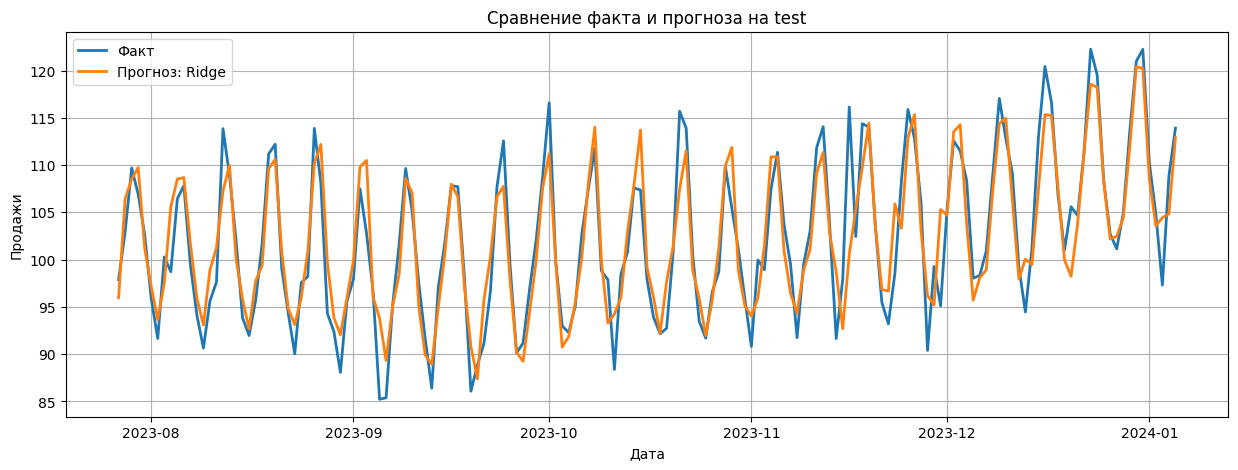

,date,actual,prediction,abs_error
0,2023-07-27,97.885141,95.965842,1.919299
1,2023-07-28,102.943528,106.429634,3.486106
2,2023-07-29,109.693496,108.504284,1.189212
3,2023-07-30,106.897179,109.738852,2.841673
4,2023-07-31,102.628238,101.193756,1.434482
5,2023-08-01,95.857034,97.139494,1.282459
6,2023-08-02,91.647057,93.640306,1.993250
7,2023-08-03,100.273292,97.539474,2.733818
8,2023-08-04,98.719427,105.586119,6.866692
9,2023-08-05,106.429859,108.512822,2.082963


,date,actual,prediction,abs_error
112,2023-11-16,116.135482,100.535988,15.599495
126,2023-11-30,95.102260,105.292382,10.190122
40,2023-09-05,85.229936,93.787327,8.557391
86,2023-10-21,115.690633,107.459915,8.230718
38,2023-09-03,102.795951,110.485791,7.689840
146,2023-12-20,105.588232,98.228244,7.359988
119,2023-11-23,98.571244,105.898697,7.327453
160,2024-01-03,97.297573,104.428424,7.130851
110,2023-11-14,91.640652,98.699811,7.059159
8,2023-08-04,98.719427,105.586119,6.866692


In [12]:
# Берём победителя по MAE на test и визуально проверяем, где именно он ошибается.
best_model_name = test_results.iloc[0]["model"]
pred_map = {
    "Naive (lag_1)": test_pred_naive,
    "MovingAverage(7)": test_pred_ma7,
    "Ridge": test_pred_ridge,
    "RandomForest": test_pred_rf,
}
best_test_pred = pred_map[best_model_name]

print(f"Лучшая модель на test по MAE: {best_model_name}")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_feat["date"], y_test.to_numpy(), label="Факт", lw=2)
ax.plot(test_feat["date"], best_test_pred, label=f"Прогноз: {best_model_name}", lw=2)
ax.set_title("Сравнение факта и прогноза на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

comparison_df = pd.DataFrame({
    "date": test_feat["date"].values,
    "actual": y_test.to_numpy(),
    "prediction": best_test_pred,
})
comparison_df["abs_error"] = np.abs(comparison_df["actual"] - comparison_df["prediction"])

# Смотрим и первые наблюдения, и самые крупные промахи модели.
display(comparison_df.head(10))
display(comparison_df.sort_values("abs_error", ascending=False).head(10))